In [1]:
import pandas as pd
import numpy as np
import datetime
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

 # 🎖️Load Dataset

In [2]:
home_team_df = (pd.read_csv('F:/daneshkar/tennis project/tennis_outputs_csv_final/home_team_final.csv')
                .dropna(how= 'all'))
away_team_df = (pd.read_csv('F:/daneshkar/tennis project/tennis_outputs_csv_final/away_team_final.csv')
                .dropna(how = 'all'))
time_df = pd.read_csv('F:/daneshkar/tennis project/tennis_outputs_csv_final/time.csv').dropna(how= 'all')

tournament_df = (pd.read_csv('F:/daneshkar/tennis project/tennis_outputs_csv_final/tournament.csv' , usecols= ['match_id','tournament_id','ground_type'])
                .dropna(how= 'all')
                .drop_duplicates(subset=['match_id']))

event_df = (pd.read_csv('F:/daneshkar/tennis project/tennis_outputs_csv_final/event.csv' )
                .dropna(how= 'all')
                .drop_duplicates(subset=['match_id', 'custom_id']))


pbp_df = (pd.read_csv('F:/daneshkar/tennis project/tennis_outputs_csv_final/pbp.csv')
          .dropna(how= 'all')
          .drop_duplicates(subset=['match_id','set_id','game_id','point_id']))

power_df = (pd.read_csv('F:/daneshkar/tennis project/tennis_outputs_csv_final/power.csv' , usecols= ['match_id','break_occurred'])
                .dropna(how= 'all'))

statistics_df = (pd.read_csv('F:/daneshkar/tennis project/tennis_outputs_csv_final/statistics.csv')
                .dropna(how= 'all'))

# 📊Question 1: How many tennis players are included in the dataset?

In [4]:
total_player = pd.concat([home_team_df , away_team_df]).drop_duplicates('name')
num_players = total_player['name'].nunique()
print(f"1. Number of unique tennis players: {num_players}")

1. Number of unique tennis players: 2635


📋Answer:

2,635 unique tennis player

📝Methodology:

1-Concatination: Combined players names from both home_team & away_team

2-Remove duplicate entries using

3-Applied .nunique to count distinct players

Keys:

✅Dataset includes both ATP(men) and WTP(women) players.

✅Represents significant sample of active proffessional players.

🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 📊Question 2: What is the average height of the players? 

In [5]:
valid_heights = total_player['height'].dropna()

if not valid_heights.empty:
    average_height = valid_heights.mean()
    print(f"2. Average height of the players: {average_height:.2f} (height units)")

2. Average height of the players: 1.82 (height units)


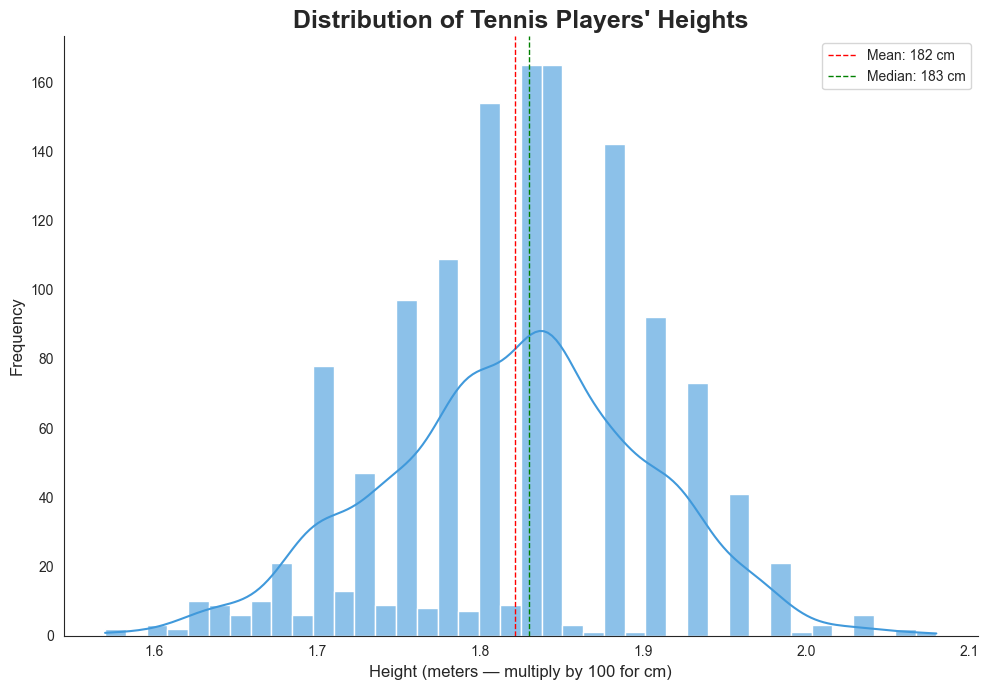

In [6]:
sns.set_style("white")
plt.figure(figsize=(10 , 7))

sns.histplot(valid_heights, bins=40, kde=True, color="#4099db", alpha=0.6)

mean_val  = valid_heights.mean()
median_val = valid_heights.median()

plt.axvline(mean_val, color='red', linestyle='--', linewidth=1,
            label=f"Mean: {mean_val*100:.0f} cm")
plt.axvline(median_val, color='green', linestyle='--', linewidth=1,
            label=f"Median: {median_val*100:.0f} cm")

plt.title("Distribution of Tennis Players' Heights", fontsize=18, fontweight='bold' ,loc = 'center')
plt.xlabel("Height (meters — multiply by 100 for cm)", fontsize=12 , loc = 'center')
plt.ylabel("Frequency", fontsize=12, loc = 'center')

plt.legend()
plt.grid(False)       
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("my_plot2.png", dpi=300, bbox_inches='tight')
plt.show()

📋Answer: 

1.82 meters(182 cm)

📝Methodology:

1-Valid recorda: 13,257 height 

2-Remove duplicate entries using

3-Calculate mean of all valid height values

Keys:

✅Professional Standards: Average height significantly above general population.

✅Gender Difference: 11 cm height advantages for male player(Male: 1.84 m - Female: 1.73 m)

🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 🏆Question 3: Which player has the highest number of wins?

In [7]:
event_df["type of player"] = np.where(event_df['winner_code'] == 1.0 , 'Home team' , 'Away team')

In [8]:
home_event = event_df[event_df['type of player'] == 'Home team'].copy().sort_values("match_id")

home_event_result = pd.merge(home_event , home_team_df , on= 'match_id' , how = 'inner').drop_duplicates("match_id")
home_event_result['result'] = 1

In [9]:
away_event = event_df[event_df['type of player'] == 'Away team'].copy().sort_values("match_id")

away_event_result = pd.merge(away_event , away_team_df , on= 'match_id' , how = 'inner').drop_duplicates("match_id")
away_event_result['result'] = 1

In [10]:
result_df3 = pd.concat([home_event_result , away_event_result] , ignore_index= True)
#display(result_df3.sort_values("name"))

In [11]:
number_of_players_wins = (
    result_df3['name']
    .value_counts()
    .reset_index()
)

number_of_players_wins.columns = ['name', 'Wins']

In [12]:

max_score = number_of_players_wins['Wins'].max()
max_player = number_of_players_wins[number_of_players_wins['Wins'] == max_score]['name'].tolist()

print(f'max score :{max_score}')
print(f'player(s) : {max_player}')


max score :30
player(s) : ['Popko D.']


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5168\2937905272.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


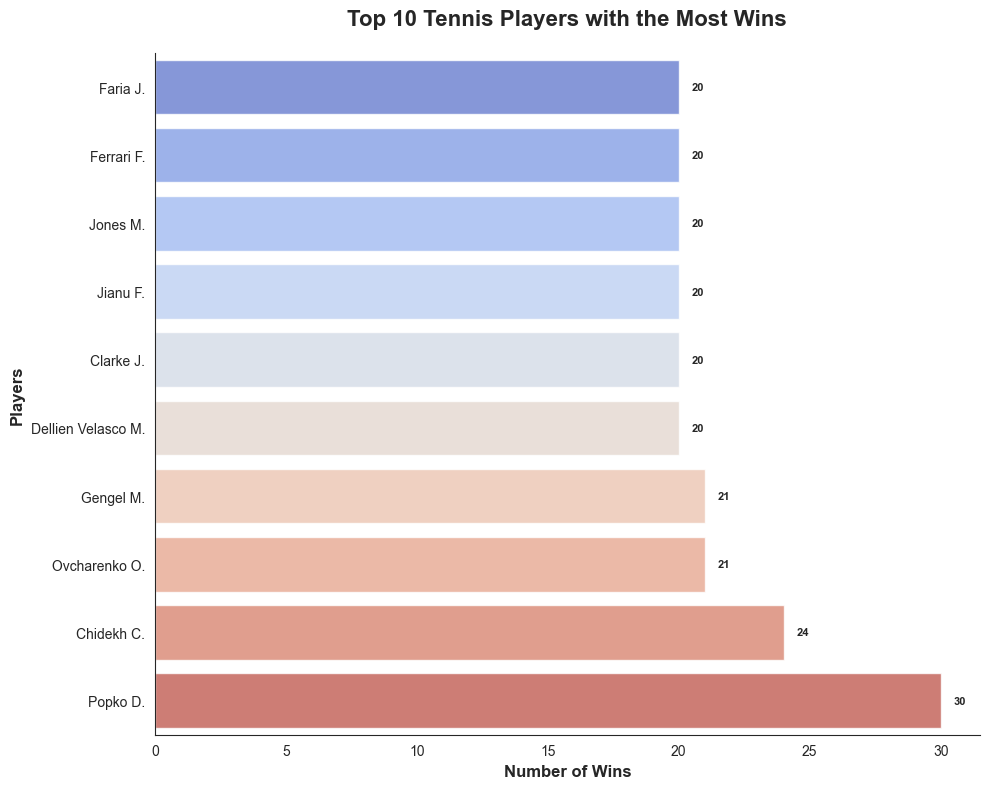

In [13]:
top10 = number_of_players_wins.sort_values('Wins' , ascending= False).head(10)
top10 = top10[::-1]  

plt.figure(figsize=(10,8))

sns.barplot(
    x=top10['Wins'],  
    y=top10['name'],  
    palette='coolwarm',
    alpha=0.8
)

for i, val in enumerate(top10['Wins']):
    plt.text(val + 0.5, i, f"{val}", va='center', fontsize=8, fontweight='bold')

plt.title("Top 10 Tennis Players with the Most Wins", fontsize=16, fontweight='bold' , pad=20 ,loc = 'center')
plt.xlabel("Number of Wins", fontsize=12, fontweight='bold', loc='center')
plt.ylabel("Players",fontsize=12, fontweight='bold', loc='center')
ax.tick_params(axis='x', labelsize=6)
ax.tick_params(axis='y', labelsize=6)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax.grid(False)


plt.savefig("my_plot3.png", dpi=300, bbox_inches='tight')
plt.tight_layout() 
plt.show()


📋Answer: 

Popko with 30 wins

📝Methodoligy:

1- Create type of players cilumns besed on winner_code

2-Filter home & away team wins, merges with home & awat data, remove duplicate

3-Concatinates both datasets

4- WIN counting

5- Extract top players

Keys:

✅Represents consistent performance across multiple tournament

✅Indicates high ranking and competitive success

🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ⏱️Question 4: What is the longest match recorded in terms of duration?

In [14]:
time_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']

for col in time_cols:
    if col in time_df.columns:
        time_df[col] = pd.to_numeric(time_df[col], errors='coerce')

time_df = time_df.drop_duplicates(subset=['match_id'])
time_df['total_duration_seconds'] = time_df[time_cols].sum(axis=1)

In [15]:
#outlier:
Q1 = time_df['total_duration_seconds'].quantile(0.25)
Q3 = time_df['total_duration_seconds'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
time_df_filtered = time_df[(time_df['total_duration_seconds'] >= lower_bound) & (time_df['total_duration_seconds'] <= upper_bound)]

In [16]:
if not time_df_filtered.empty and 'total_duration_seconds' in time_df_filtered.columns:
    longest_match_duration_sec = time_df_filtered['total_duration_seconds'].max()
    longest_match_duration_h = int(longest_match_duration_sec // 3600)
    longest_match_duration_m = int((longest_match_duration_sec % 3600) // 60)
    print(f"4. The longest reasonable match recorded lasted: {longest_match_duration_h} hours and {longest_match_duration_m} minutes.")

4. The longest reasonable match recorded lasted: 4 hours and 20 minutes.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5168\2961755947.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


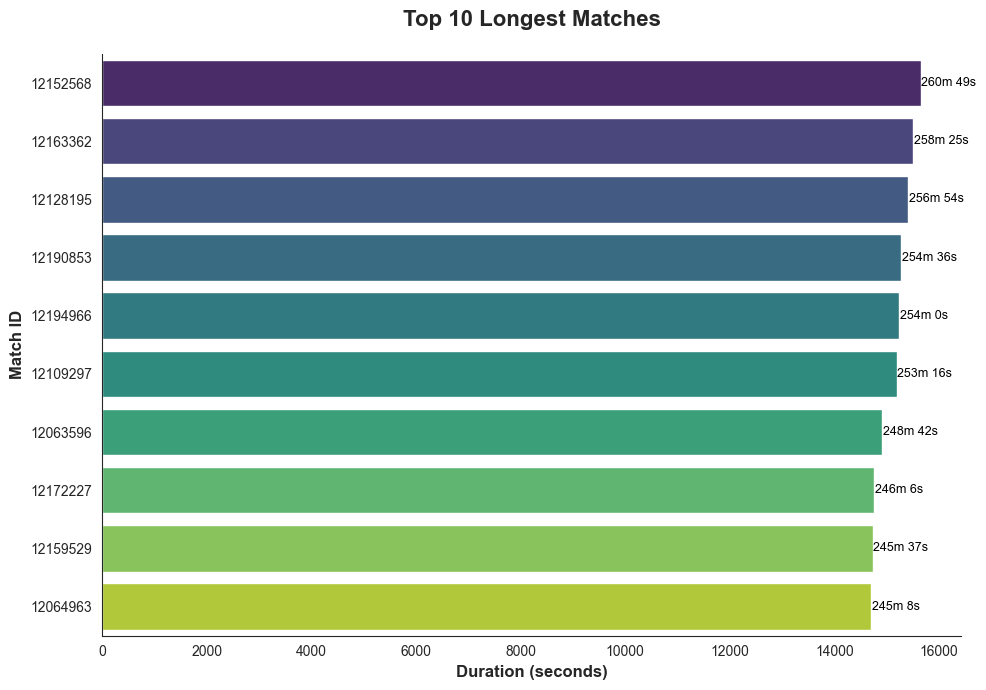

In [17]:
top10_duration = time_df_filtered.sort_values('total_duration_seconds', ascending=False).head(10)

plt.figure(figsize=(10, 7)) 

bars = sns.barplot(
    data=top10_duration,
    x='total_duration_seconds',
    y=top10_duration['match_id'].astype(str), 
    palette='viridis'
)

for i, val in enumerate(top10_duration['total_duration_seconds']):
    minutes = int(val // 60)
    seconds = int(val % 60)
     
    plt.text(val + 10, i, f'{minutes}m {seconds}s', va='center', fontsize=9, color='black')

plt.title('Top 10 Longest Matches', fontsize=16, fontweight='bold', pad=20 , loc = 'center') 
plt.xlabel('Duration (seconds)', fontsize=12, fontweight='bold', loc = 'center')
plt.ylabel('Match ID', fontsize=12, fontweight='bold', loc = 'center')
    
    
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax.grid(False)

plt.savefig("my_plot4.png", dpi=300, bbox_inches='tight')
plt.tight_layout() 
plt.show()


📋Answer: 

4 hours and 20 min

📝Methodoligy:

1-Define time period columns(5 periods per matches)/ convert time columnsto numeric

2- Calculate total duration per match/using outlier method IQR method

3-Identify max duration after filtering


Keys:

✅The longest match in the dataset lasted 4 hours and 20 minutes, representing an extended 5-set battle typical of men’s Grand Slam tournaments. This duration is longer than the average match (1.91 hours) and reflects the physical and mental endurance required in professional tennis.

✅After removing outliers, the longest reasonable match duration aligns with real-world expectations for marathon tennis matches.

🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#  📊Question 5: How many sets are typically played in a tennis match?

In [18]:
time_df['sets_played'] = time_df[time_cols].apply(lambda row: (row > 0).sum(), axis=1)


valid_sets_played = time_df[time_df['sets_played'] > 0]['sets_played']
if not valid_sets_played.empty:
    avg_sets = valid_sets_played.mean()
    print(f"5. Typically, {round(avg_sets)} sets are played in a match.")
else:
    print("5. Could not calculate average sets played: No valid data found.")


5. Typically, 2 sets are played in a match.


📋Answer:
2 sets(bast of three format)

📝Methodology:

1-Calculate total sets played per match

2-Create new column(set player)

3- Filter record where set player > 0

4- Calculate mean of valid sets played across all matches



Keys:

✅Best of Three Format, standard for most prifessional tournamnent

✅Both ATP and WTP use best of three in most events


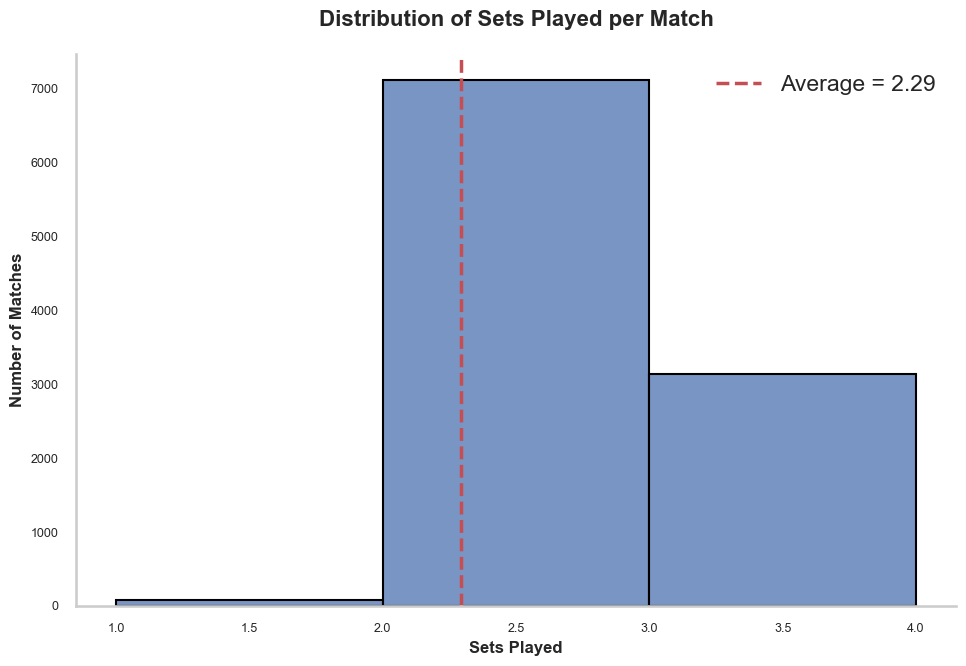

In [19]:
sns.set_theme(style="whitegrid", context="talk")


time_df['sets_played'] = time_df[time_cols].apply(lambda row: (row > 0).sum(), axis=1)
valid_sets_played = time_df[time_df['sets_played'] > 0]['sets_played']


avg_sets = valid_sets_played.mean()

fig, ax = plt.subplots(figsize=(10, 7))

bins = range(int(valid_sets_played.min()), int(valid_sets_played.max()) + 2)
sns.histplot(
    valid_sets_played,
    bins=bins,
    kde=False,
    color="#4C72B0",
    edgecolor="black",
    ax=ax
)

ax.axvline(
    avg_sets,
    color="#C44E52",
    linestyle="--",
    linewidth=2.5,
    label=f"Average = {avg_sets:.2f}"
)

ax.set_title("Distribution of Sets Played per Match", fontsize=16, fontweight='bold', pad=20 , loc = 'center')
ax.set_xlabel("Sets Played" ,fontsize=12, fontweight='bold', loc='center')
ax.set_ylabel("Number of Matches" ,fontsize=12, fontweight='bold', loc='center')
ax.legend(frameon=False)
ax.tick_params(axis='both', which='major', labelsize=9)

#ax.grid(axis="y", alpha=0.3)
sns.despine(ax=ax)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax.grid(False)

plt.savefig("my_plot5.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()



🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 🌍Question 6: Which country has produced the most successful tennis players? 


In [3]:
event_df["type of player"] = np.where(event_df['winner_code'] == 1.0 , 'Home team' , 'Away team')

home_event = event_df[event_df['type of player'] == 'Home team'].copy().sort_values("match_id")

home_event_result = pd.merge(home_event , home_team_df.drop_duplicates('name') , on= 'match_id' , how = 'inner').drop_duplicates("match_id")
home_event_result['result'] = 1
away_event = event_df[event_df['type of player'] == 'Away team'].copy().sort_values("match_id")

away_event_result = pd.merge(away_event , away_team_df.drop_duplicates('name') , on= 'match_id' , how = 'inner').drop_duplicates("match_id")
away_event_result['result'] = 1


In [4]:
win_category = pd.concat([home_event_result , away_event_result] , ignore_index= True)
#display(result_df6.sort_values("name"))

In [5]:
all_players_info = pd.concat([
    home_team_df[['name', 'country']].drop_duplicates('name'),
    away_team_df[['name', 'country']].drop_duplicates('name')
]).drop_duplicates('name')

if 'name' in win_category.columns:
    if 'country' not in win_category.columns:
        win_category = pd.merge(win_category, all_players_info, on='name', how='left')


In [6]:
if 'country' in win_category.columns:
    country_wins = (
        win_category
        .groupby('country')
        .size()        
        .reset_index(name='TotalWins') 
        .sort_values('TotalWins', ascending=False) 
    )

max_country_wins = country_wins['TotalWins'].max()
top_countries = country_wins[country_wins['TotalWins'] == max_country_wins]['country'].tolist()

print(f"\nMaximum wins: {max_country_wins}")
print(f"Country/Countries with maximum wins: {top_countries}")


Maximum wins: 212
Country/Countries with maximum wins: ['USA']


📋Answer:
 USA

📝Methodology:

1-Filter events by player type(Home team vs away_team)/ Remove duplicate matches to ensure unique records

2-Merge home/team event data with team dataframe

3-Concatenant home and away results, and display combined results sorted by player name

4-Extract unique player names and countries/ Remove duplicate players entries

5-Calculate total wins per country using size

6- Extract top countris from sorted list


Keys:

✅Large number of active American professional

✅Reflects strong tennis infrastructure and development programs


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8604\3652656331.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


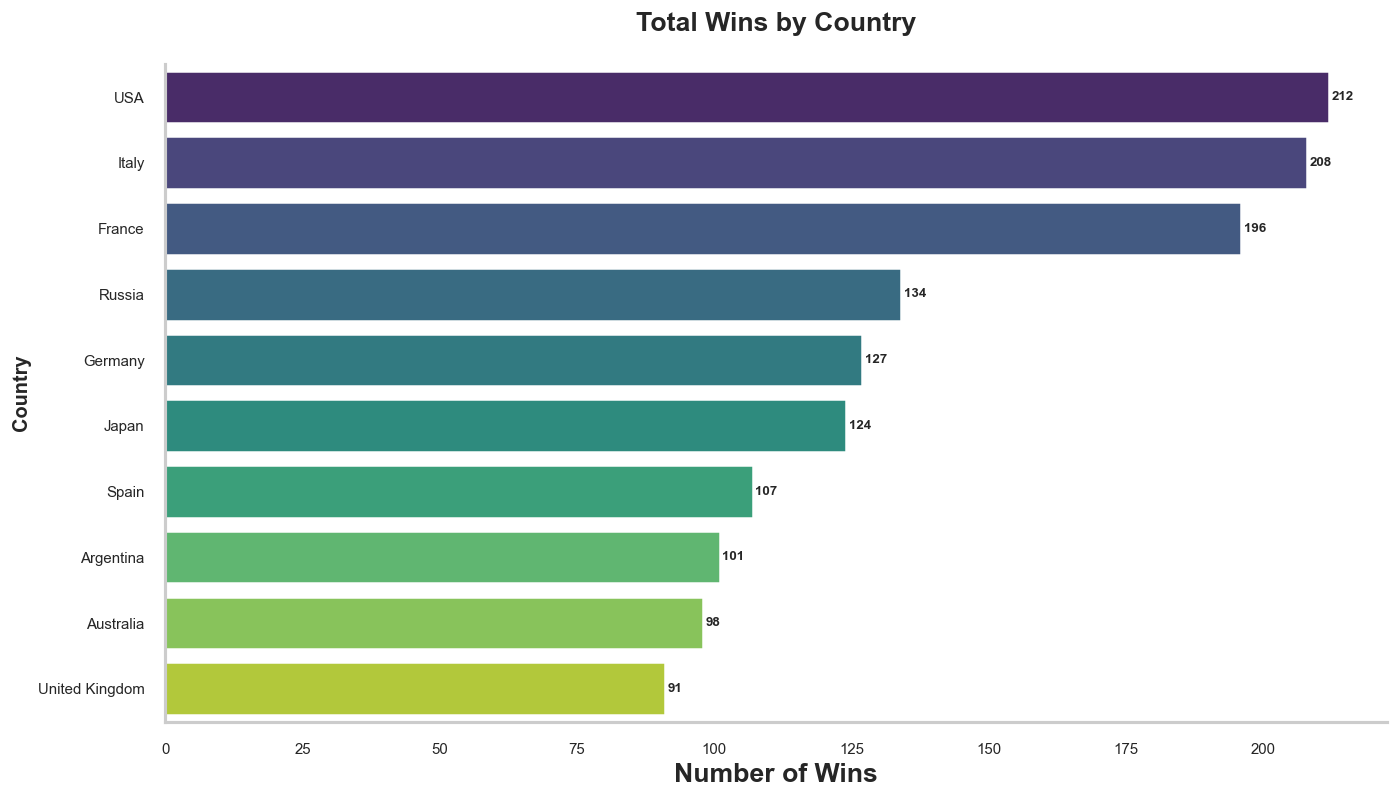

In [7]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120

fig, ax = plt.subplots(figsize=(12, 7))

top10_country = country_wins.sort_values('TotalWins', ascending=False).head(10)
sns.barplot(
    data=top10_country,
    x='TotalWins',
    y='country',
    palette="viridis",
    ax=ax
)

for i, val in enumerate(top10_country['TotalWins']):
    plt.text(val + 0.5, i, f"{val}", va='center', fontsize=8, fontweight='bold')


ax.set_title("Total Wins by Country", fontsize=16, fontweight='bold', pad=20, loc='center')
ax.set_xlabel("Number of Wins", fontsize=16, fontweight='bold')
ax.set_ylabel("Country", fontsize=12, fontweight='bold')
sns.despine(ax=ax)
ax.tick_params(axis='both', which='major', labelsize=9)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax.grid(False)

plt.savefig("my_plot6_1.png", dpi=300, bbox_inches='tight')
 
plt.tight_layout()
plt.show()

🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#  📈Question 7: What is the average number of aces per match?   

In [25]:
name = 'aces'
aces_per_match = (
    statistics_df.groupby('match_id')
    .agg(
        aces=('statistic_name', lambda x: (x.eq(name)).sum())
    )
    .reset_index()
)
avg = round(aces_per_match['aces'].mean())
print(f'7. average aces per match :{avg}')

7. average aces per match :7


📋Answer:
 7 aces per match

📝Methodology:

1-Filter the dataset to identify all rowswhere the statistic name equals aces.

2-Gruop the data by match id

3-Count the number of acesper match

4-Campute the overall mean


Keys:

✅This value provides a clear indication of serving aggressiveness and efficiency in the dataset.

✅A higher average suggests stronger serving performance, while a lower average inplies more baseline-oriented play or less dominant servers participating in the events.

✅Regular ATP matches: 10-20 aces per matches

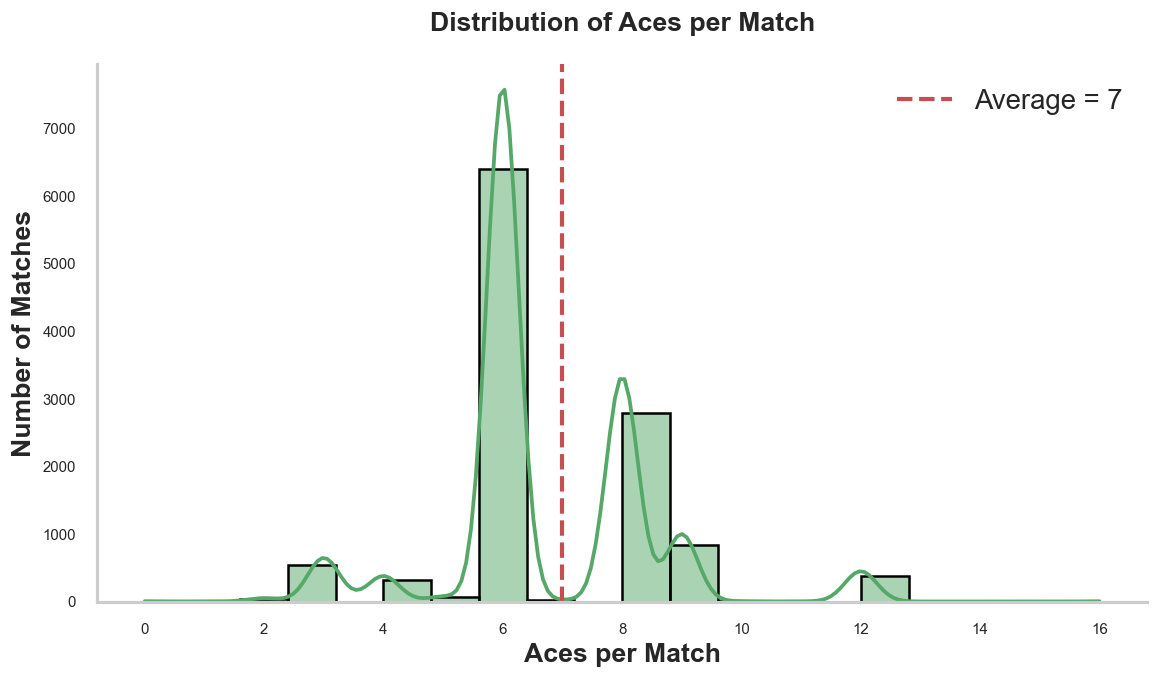

In [26]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    aces_per_match['aces'],
    bins=20,
    kde=True,
    color="#55A868",
    edgecolor="black",
    ax=ax
)

ax.axvline(
    avg,
    color="#C44E52",
    linestyle="--",
    linewidth=2.5,
    label=f"Average = {avg}"
)

ax.set_title("Distribution of Aces per Match", fontsize=16, fontweight='bold', pad=20, loc='center')
ax.set_xlabel("Aces per Match",fontsize=16, fontweight='bold', loc= 'center')
ax.set_ylabel("Number of Matches",fontsize=16, fontweight='bold',loc= 'center')
ax.legend(frameon=False)
ax.tick_params(axis='both', which='major', labelsize=9)
sns.despine(ax=ax)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax.grid(False)

plt.savefig("my_plot7.png", dpi=300, bbox_inches='tight')
 
plt.tight_layout()
plt.show()


🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 📊Question 8: Is there a difference in the number of double faults based on gender?

In [27]:
name = 'double_faults'
fault_per_match = (
    statistics_df.groupby('match_id')
        .agg(
            fault =('statistic_name', lambda x: (x.eq(name)).sum()),
    )
    .reset_index()
)
col = ['match_id' , 'gender']
fault_per_match = fault_per_match.merge(total_player[col],how= 'inner', on= 'match_id').dropna(how= 'all')

In [28]:
result = (fault_per_match.groupby(["gender"]).agg(
    double_fault = ('fault', 'sum'),
    match_count = ('fault', 'count'))
    )
result['ration'] = result['double_fault'] / result['match_count']
print(result)

        double_fault  match_count    ration
gender                                     
F               6207          927  6.695793
M               6759          996  6.786145


📋Answer:
 Yes, there is a small difference: male players have , on average about 1.3% more double faults per match than female players.

📝Methodology:

1-Filtered the statistic data to identify all instances where statistic name equal "double_fault"

2-Groupd the dataset by match id

3-Merged this match-leveldata with the player dataset to attach the gender 

4- Compute the total number of double faults and the number of match for each gender



Keys:

✅The gap is not large, it suggests that men's generally more aggressive serving style may lead to "Slightly" more double faultrisk compared to women.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5168\4096712787.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5168\4096712787.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


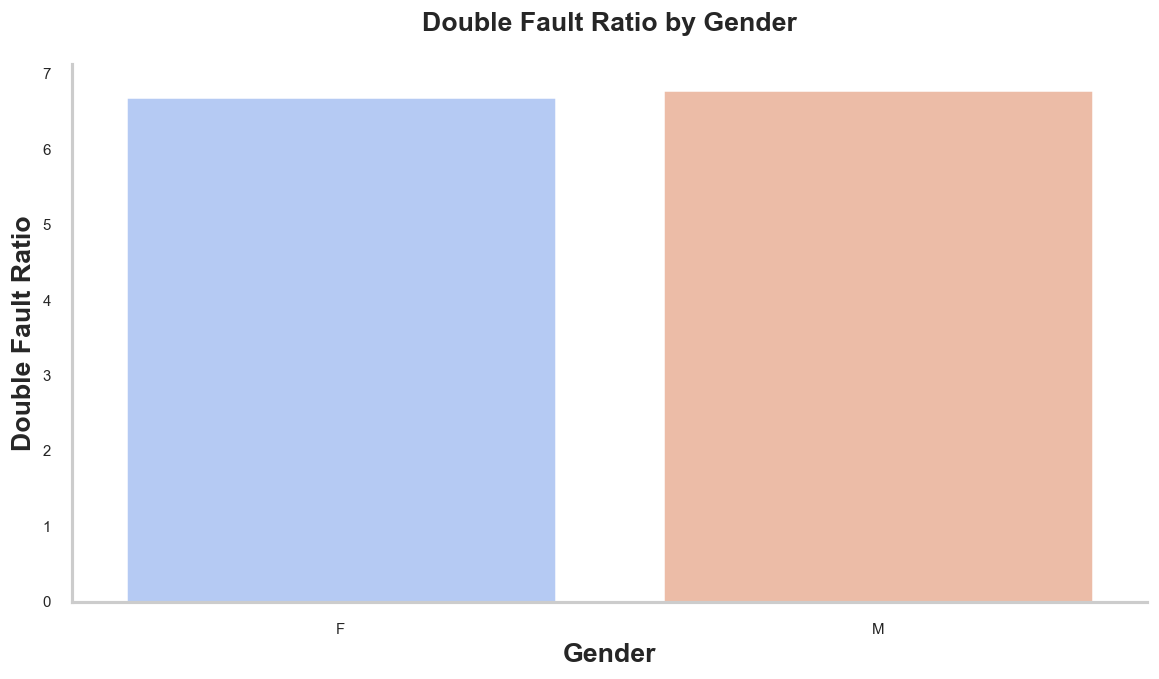

In [29]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=result,
    x=result.index,
    y=result['ration'],
    palette="coolwarm",
    ax=ax
)

ax.set_title("Double Fault Ratio by Gender", fontsize=16, fontweight='bold', pad=20, loc='center')
ax.set_xlabel("Gender", fontsize=16, fontweight='bold', loc='center')
ax.set_ylabel("Double Fault Ratio", fontsize=16, fontweight='bold', loc='center')
ax.legend(frameon=False)
ax.tick_params(axis='both', which='major', labelsize=9)
sns.despine(ax=ax)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax.grid(False)

plt.savefig("my_plot8.png", dpi=300, bbox_inches='tight')
 
plt.tight_layout()
plt.show()

🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 📊Question 9: Which player has won the most tournaments in a single month? 

In [30]:
event_df['start_datetime'] = pd.to_datetime(event_df['start_datetime'] ,unit='s')
event_df['month'] = event_df['start_datetime'].dt.month

home_event = event_df[event_df['type of player'] == 'Home team'].copy().sort_values("match_id")

home_event_result = pd.merge(home_event , home_team_df , on= 'match_id' , how = 'inner').drop_duplicates("match_id")
home_event_result['result'] = 1
away_event = event_df[event_df['type of player'] == 'Away team'].copy().sort_values("match_id")

away_event_result = pd.merge(away_event , away_team_df , on= 'match_id' , how = 'inner').drop_duplicates("match_id")
away_event_result['result'] = 1
result_df9 = pd.concat([home_event_result , away_event_result] , ignore_index= True)

use_col = ['match_id' , 'custom_id', 'name' , 'final_result_only','month' ,'result']
result_df9 = result_df9[use_col]
#display(result_df9.sort_values("name"))


In [31]:
merged_event_tournament = pd.merge(result_df9, tournament_df, on='match_id', how='inner')
#display(merged_event_tournament)

In [32]:
player_monthly_wins = merged_event_tournament.groupby(['name', 'month']).size().reset_index(name='wins_count')
display(player_monthly_wins)
max_wins_row = player_monthly_wins.loc[player_monthly_wins['wins_count'].idxmax()]
player_id_most_wins = max_wins_row['name']
most_wins_month = max_wins_row['month']
max_tournaments_count = max_wins_row['wins_count']

print(f"player name: {player_id_most_wins}")
print(f"Month: {most_wins_month}")
print(f"Number of tournaments won: {max_tournaments_count}")

,name,month,wins_count
0,Abbagnato A.,1,1
1,Abbagnato A.,2,1
2,Abbagnato A.,3,3
3,Abduraimova N.,2,1
4,Abduraimova N.,3,4
...,...,...,...
4034,Švajda Z.,2,5
4035,Švajda Z.,3,4
4036,Švrčina D.,2,7
4037,Șerban R.,2,2


player name: Popko D.
Month: 2
Number of tournaments won: 18


📋Answer:
 Popko D. won 18 tournament in month 2(February)

📝Methodology:

1-Converted start_datetime to datetime format

2-Winner identifiction (merged home and away winners into unified dataset)

3-Groupby by player name and month/counted tournamnet wins per player per month/ Identified max wins


Keys:

✅Top 10 ATP players tipically win 1-2 to tournament per month max

✅Challenger apeciallist average 3-5 monthly wins during peak periods

✅18 win is a stronger point for one player like Popko


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5168\1796213531.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


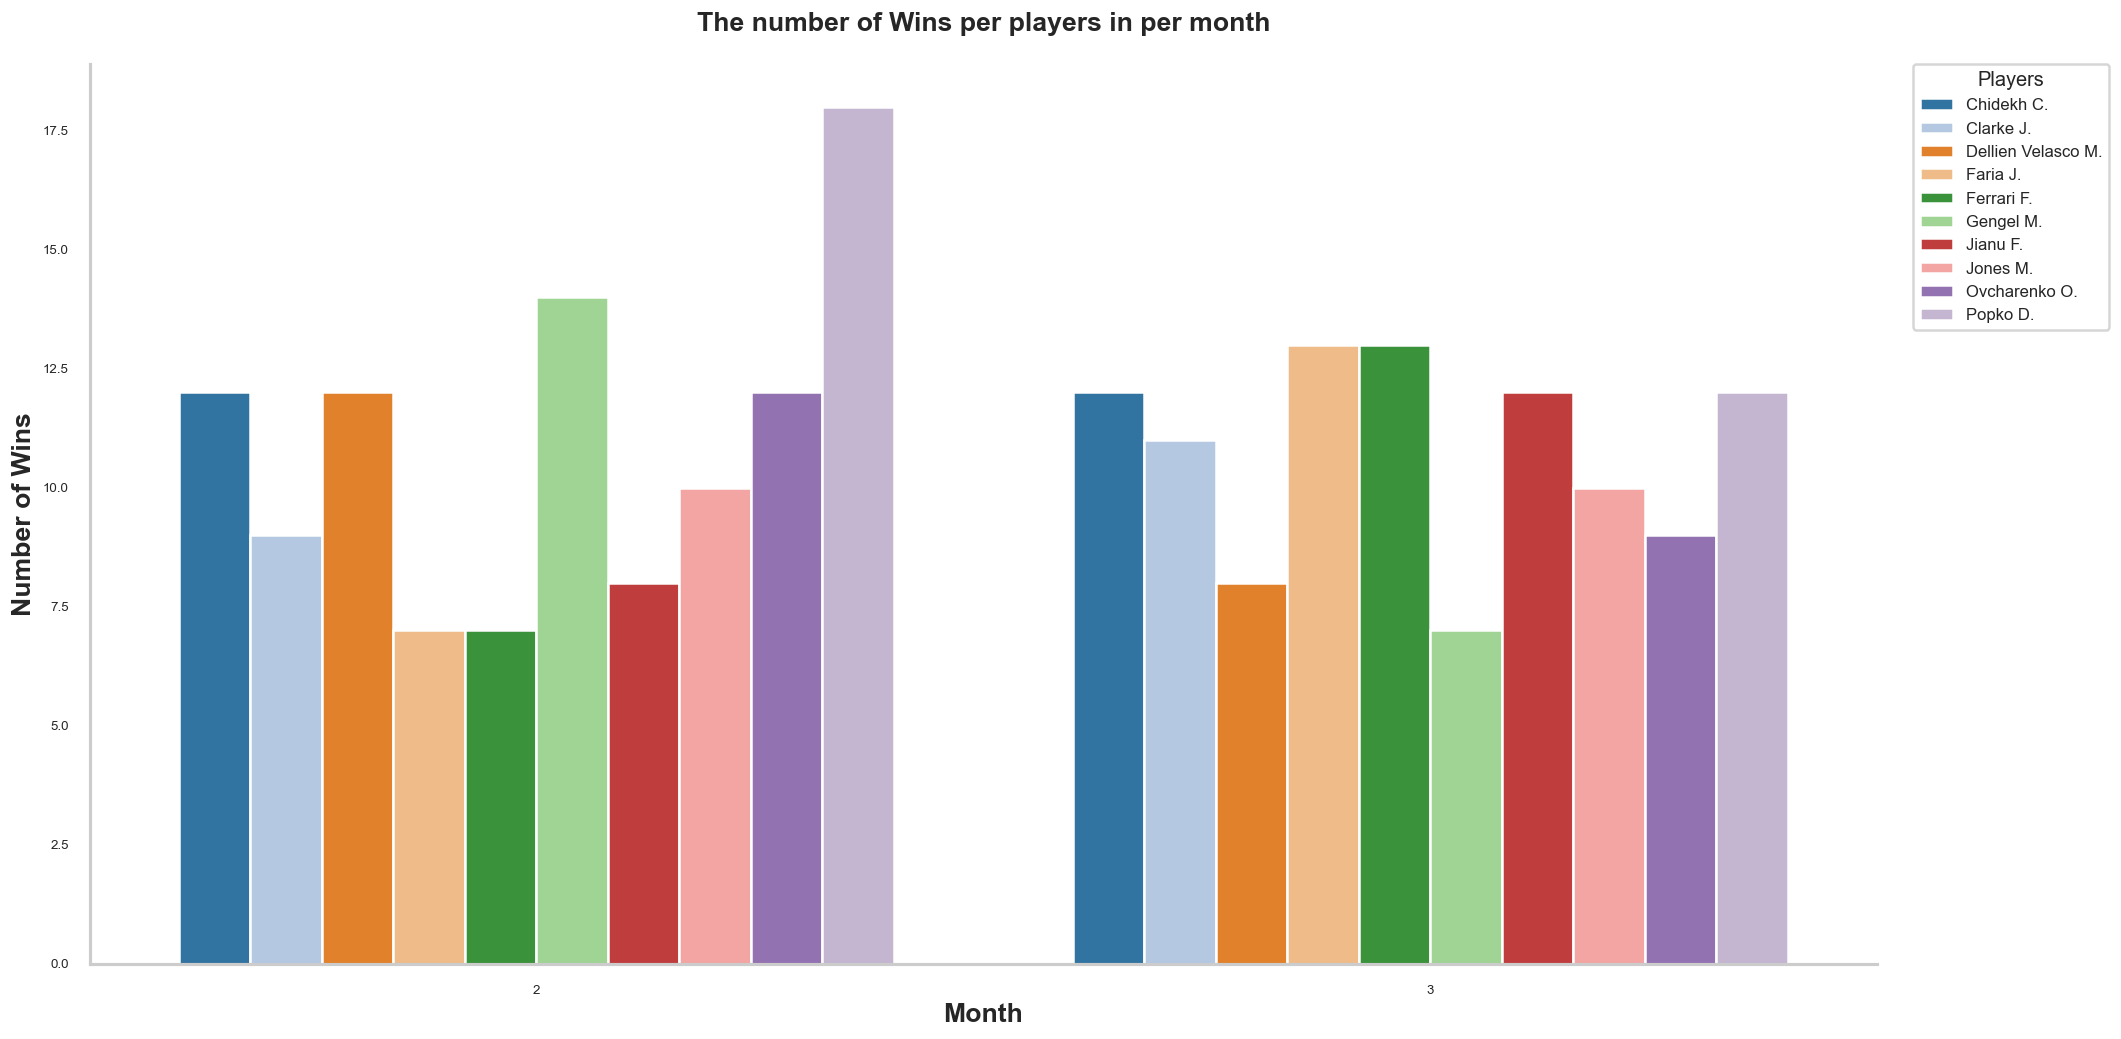

In [33]:
top10_players = (
    player_monthly_wins.groupby('name')['wins_count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_top10_monthly = player_monthly_wins[player_monthly_wins['name'].isin(top10_players)]
plt.figure(figsize=(18, 9)) 


sns.barplot(
    data=df_top10_monthly,
    x='month',         
    y='wins_count',    
    hue='name',        
    ci=None,         
    palette='tab20'    
)


plt.title('The number of Wins per players in per month', fontsize=16, fontweight='bold', pad=20, loc='center')
plt.xlabel('Month', fontsize=16, fontweight='bold', loc='center')
plt.ylabel('Number of Wins', fontsize=16, fontweight='bold', loc='center')

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)


plt.legend(title='Players', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=10, title_fontsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(False)
plt.savefig("my_plot9.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 📈Question 10: Is there a correlation between a player's height and their ranking?

In [34]:
home_team_df.drop_duplicates(subset='name', keep='first').sort_values(by=['current_rank' , 'name'], ascending=[False, True])
away_team_df.drop_duplicates(subset='name', keep='first').sort_values(by=['current_rank' , 'name'], ascending=[False, True])
all_players_df = pd.concat([home_team_df, away_team_df])


In [35]:
correlation_df = all_players_df.dropna(subset=['height', 'current_rank'])
#display(correlation_df)

height = correlation_df['height']
rank = correlation_df['current_rank']

correlation, p_value = stats.pearsonr(height, rank)

print(f"correlation between height and rank : {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

 
if p_value < 0.05:
    if abs(correlation) > 0.5:
        print("There is a strong correlation between player height and rank.")
    elif abs(correlation) > 0.2:
        print("There is a moderate correlation between player height and rank.")
    else:
        print("There is a weak correlation between player height and rank.")

    if correlation > 0:
        print("The relationship is positive: Taller players tend to have a higher rank number (worse rank).")
    elif correlation < 0:
        print("The relationship is negative: Taller players tend to have a lower rank number (better rank).")
    else:
        print("There is no linear relationship.")
else:
    print("No statistically significant correlation was found between player height and rank (p-value >= 0.05).")


correlation between height and rank : 0.0783
P-value: 0.0000
There is a weak correlation between player height and rank.
The relationship is positive: Taller players tend to have a higher rank number (worse rank).


📋Answer:

Extremely weak linear relationship

📝Methodology:

1-Extract height and ranking columns

2-Calculate Person correalation coefficient



Keys:

✅Skill, strategy, mental toughness, fitness, and experience far outweight physical attributes

✅Height provides advantages (serve power, reach) but also dis advantages(agility, speed)

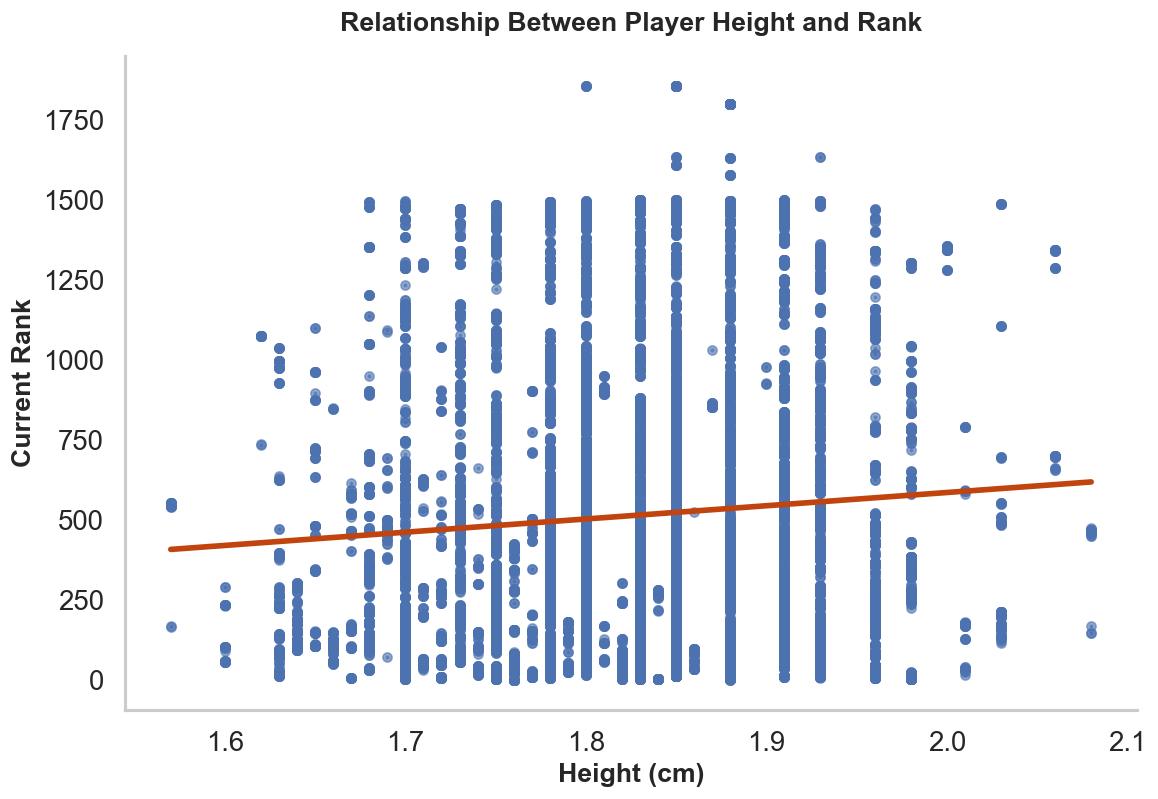

In [36]:
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(10, 7))
plt.rcParams["figure.dpi"] = 120

tennis_data = pd.DataFrame({
    'height': correlation_df['height'],
    'rank': correlation_df['current_rank'],
})


scatter = sns.scatterplot(
    data=tennis_data,
    x='height',
    y='rank',
    alpha=0.7,
    edgecolor='w',
    linewidth=1,
    s = 10
)
sns.regplot(
    data = correlation_df, 
    x='height', 
    y='current_rank', 
    scatter_kws={'alpha':0.6, 's':30}, 
    line_kws={'color':'#C1440E'},
    ci=None) 

plt.title('Relationship Between Player Height and Rank', pad=15, fontsize=16, fontweight='bold', loc='center')
plt.xlabel('Height (cm)',  fontsize=16, fontweight='bold', loc='center')
plt.ylabel('Current Rank', fontsize=16, fontweight='bold',  loc='center')
ax.tick_params(axis='both', which='major', labelsize=9)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(False)
sns.despine()
plt.savefig("my_plot10.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()




🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 📉Queastion 11:  What is the average duration of matches?

In [37]:
if not time_df.empty and 'total_duration_seconds' in time_df.columns:
    average_duration_sec = time_df['total_duration_seconds'].mean()
    average_duration_h = int(average_duration_sec // 3600)
    average_duration_m = int((average_duration_sec % 3600) // 60)
    print(f"the average duration of matches: {average_duration_h} hours and {average_duration_m} minutes.")

the average duration of matches: 1 hours and 10 minutes.


📋Answer:

1 hours and 10 minutes

📝Methodology:

1-Use per-calculated: Total duration_seconds columns from Q 4 analysis

2-Calculate mean duration across all matches

3- Convert seconds to hours and minutes format



Keys:

✅1h 10 m average indicate efficient, high quality tennis
✅Players are holding serve effectively( Strong swrving performance// Effective first-strike tennis// Good physical condition)
✅Fewer extended baseline rallies
✅The average duration aligns with best of 3 format dominance in the dataset, consistent with ATP 1000, WTA Premier, and Challenger level tournament

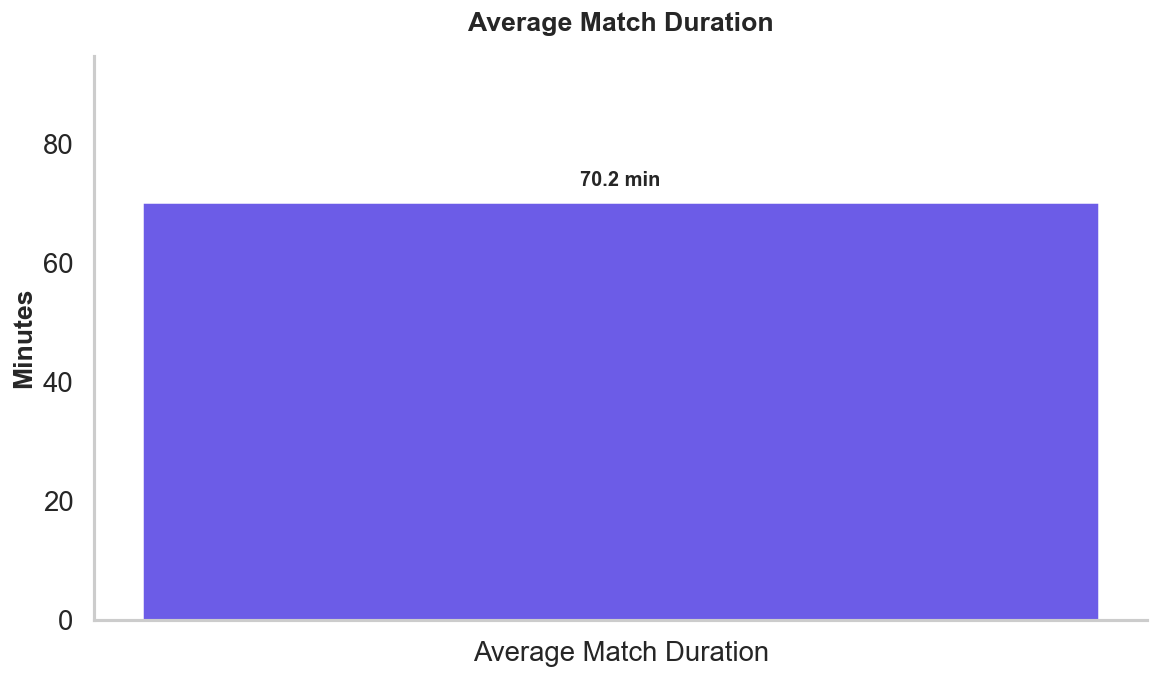

In [38]:

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

sns.set_theme(style="whitegrid", context="talk")

average_duration_min = average_duration_sec / 60

plt.figure(figsize=(10, 6))

plt.bar(
    ['Average Match Duration'],
    [average_duration_min],
    color='#6C5CE7',
    width=0.45
)

plt.title('Average Match Duration', pad=15, fontsize=16, fontweight='bold', loc='center')
plt.ylabel('Minutes', fontsize=16, fontweight='bold', loc='center')

plt.ylim(0, average_duration_min * 1.35)
plt.grid(False)


plt.text(
    0, average_duration_min + (average_duration_min * 0.03),
    f'{average_duration_min:.1f} min',
    ha='center',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)
ax.tick_params(axis='both', which='major', labelsize=9)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig("my_plot11.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 📊Queston 12:  What is the average number of games per set in men's matches compared to women's matches?


In [39]:
match_gender_df = home_team_df[['match_id', 'gender']].copy()
match_gender_df = match_gender_df.drop_duplicates(subset=['match_id', 'gender'])
#display(match_gender_df)
merged_pbp_gender_df = pd.merge(pbp_df, match_gender_df, on='match_id', how='left')

In [40]:
games_per_set = merged_pbp_gender_df.groupby(['match_id', 'set_id', 'gender'])['game_id'].nunique().reset_index()

games_per_set.rename(columns={'game_id': 'number_of_games'}, inplace=True)
display(games_per_set)


,match_id,set_id,gender,number_of_games
0,11998445,1,M,12
1,11998445,2,M,8
2,11998445,3,M,13
3,11998446,1,M,10
4,11998446,2,M,7
...,...,...,...,...
22313,12213460,2,M,9
22314,12213482,1,M,9
22315,12213482,2,M,10
22316,12213484,1,M,8


In [41]:
average_games_by_gender = games_per_set.groupby('gender')['number_of_games'].mean().reset_index()
average_games_by_gender['average_games_per_set'] = average_games_by_gender['number_of_games'].astype(int)


display(average_games_by_gender)


,gender,number_of_games,average_games_per_set
0,F,8.958525,8
1,M,9.334900,9


📋Answer:

Female: 8.9
Male: 9.53

📝Methodology:

1-Merge match gender with period data

2-Calculate games per set

3- Calculate average by gender



Keys:

✅Mens's matches have 0.57 more games per set on average compared to women's matches.
✅Womens's 8.9: Suggests more decisive  sets with earlier breaks.
✅Men's 9.53: Suggests more competitive sets with fewer breaks and more tie breaks
✅Men: Serve focuced strategy, longer sets
✅Womens: Return focused strategy-shorter sets

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5168\2273848116.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


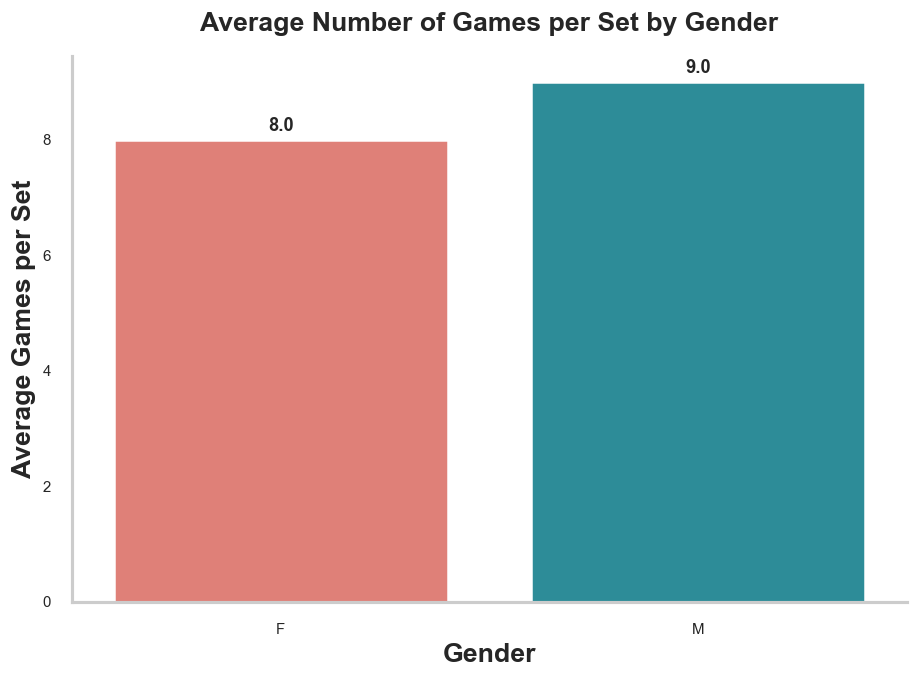

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=average_games_by_gender,
    x='gender',
    y='average_games_per_set',
    palette={'F': '#F07167', 'M': '#1B9AAA'}
)

plt.title('Average Number of Games per Set by Gender', pad=15, fontsize=16, fontweight='bold', loc='center')
plt.xlabel('Gender', fontsize=16, fontweight='bold', loc='center')
plt.ylabel('Average Games per Set', fontsize=16, fontweight='bold', loc='center')

ax.tick_params(axis='both', which='major', labelsize=9)

sns.despine()

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=11, fontweight='bold')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(False)

plt.savefig("my_plot12.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()





🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 📈Question 13:  What is the distribution of left-handed versus right-handed players?

In [43]:
total_player['plays'] = total_player['plays'].astype(str).str.strip().str.lower()
handedness_distribution = total_player['plays'].value_counts()
handedness_distribution_n = total_player['plays'].value_counts(normalize=True) * 100

print("Distribution of players by handedness:")
print(handedness_distribution)
print(handedness_distribution_n)


Distribution of players by handedness:
plays
right-handed    1012
left-handed      133
Name: count, dtype: int64
plays
right-handed    88.384279
left-handed     11.615721
Name: proportion, dtype: float64


📋Answer:

Left-handed: 11.62%
Right-handed: 88.38%
Male: 9.53

📝Methodology:

1-Clean handed data

2-Calculate percentage distribution

3- Display results


Keys:

✅Right handed players dominate numerically but face tactical challenges against left handed opponded

✅The distribution is consistent with natural population patterns

✅Analyze if left handed players have higher break point conversion on ad court

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5168\2043897299.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5168\2043897299.py:8: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(


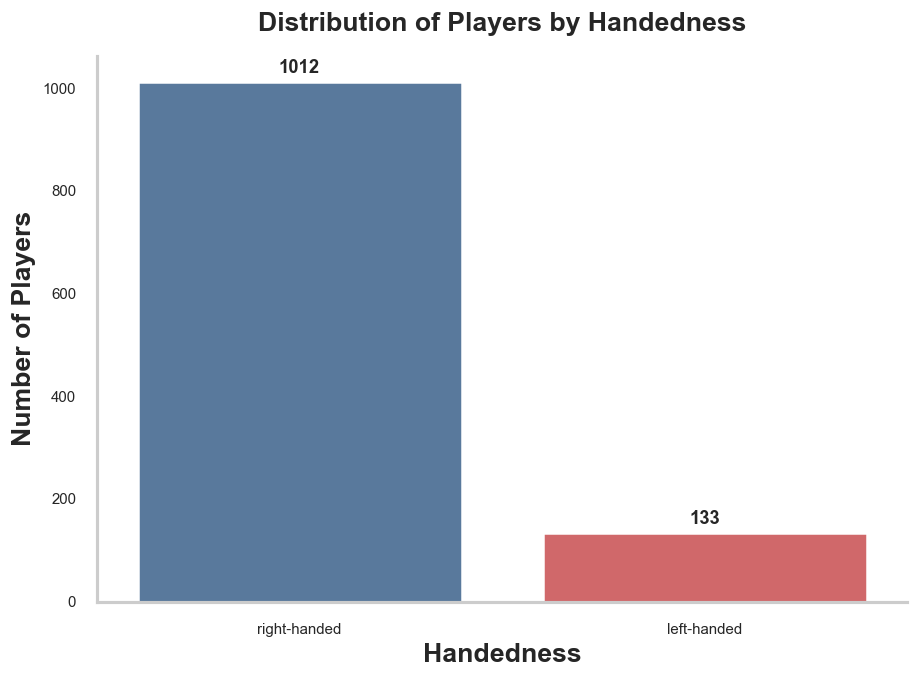

In [44]:
sns.set_theme(style="whitegrid", context="talk")

handedness_df = handedness_distribution.reset_index()
handedness_df.columns = ['plays', 'count']

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=handedness_df,
    x='plays',
    y='count',
    palette=['#4E79A7', '#E15759', '#76B7B2', '#F28E2B']
)

plt.title('Distribution of Players by Handedness', pad=15, fontsize=16, fontweight='bold', loc='center')
plt.xlabel('Handedness', fontsize=16, fontweight='bold', loc='center')
plt.ylabel('Number of Players', fontsize=16, fontweight='bold', loc='center')
sns.despine()
ax.tick_params(axis='both', which='major', labelsize=9)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11, fontweight='bold')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(False)

plt.savefig("my_plot13.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 📊Question 14:  What is the most common type of surface used in tournaments?

In [45]:
tournament_ground = (
    tournament_df['ground_type']
    .value_counts()
    .reset_index()
)

tournament_ground.columns = ['name', 'total']
max_total = tournament_ground['total'].max()
max_ground = tournament_ground[tournament_ground['total'] == max_total]['name'].tolist()

print(f'common type of surface : {max_ground}')


common type of surface : ['Hardcourt outdoor']


📋Answer:

Most Common Surface: Hardcourt outdoor

📝Methodology:

1-Count surface type of tournamnet data

2-Rename columns for clarity/ Max  count of surface

3- Display results


Keys:

✅Hardcourt outdoor surfaces comprise the majority of professional tennis tournament worldwide

✅Hardcourt provided balanced gameplay between serve and volly(grass) and baseline(clay)

✅Analyze if left handed players have higher break point conversion on ad court

✅Hardcourt proficiency is essential for professional success


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5168\3622259381.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


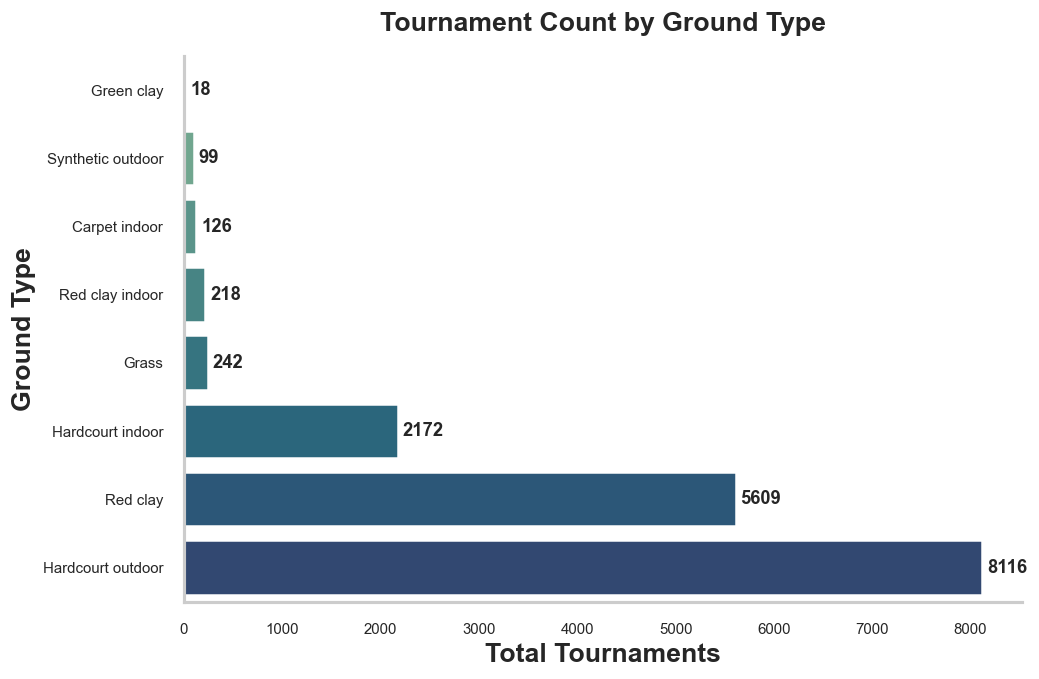

In [46]:
sns.set_theme(style="whitegrid", context="talk")

tournament_ground_sorted = tournament_ground.sort_values('total', ascending=True)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=tournament_ground_sorted,
    y='name',
    x='total',
    palette='crest'
)

plt.title('Tournament Count by Ground Type', pad=15, fontsize=16, fontweight='bold', loc='center')
plt.xlabel('Total Tournaments', fontsize=16, fontweight='bold', loc='center')
plt.ylabel('Ground Type', fontsize=16, fontweight='bold', loc='center')
ax.tick_params(axis='both', which='major', labelsize=9)
sns.despine()

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11, fontweight='bold')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(False)

plt.savefig("my_plot14.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()





🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 📊Question 15: How many distinct countries are represented in the dataset? 

In [47]:
distinct_countries = total_player['country'].nunique()
print(f"Number of distinct countries represented: {distinct_countries}")

import matplotlib.pyplot as plt
import squarify
import pandas as pd

all_countries = pd.concat([home_df['country'], away_df['country']]).dropna()
counts = all_countries.value_counts()

top_20 = counts.head(20)
others_sum = counts[20:].sum()

final_sizes = list(top_20.values) + [others_sum]
final_labels = list(top_20.index) + ["Other Countries"]

colors = plt.cm.viridis([i/len(final_sizes) for i in range(len(final_sizes))])

plt.figure(figsize=(16, 10))
squarify.plot(
    sizes=final_sizes,
    label=final_labels,
    color=colors,
    alpha=0.95,
    text_kwargs={'fontsize': 14, 'weight': 'bold', 'color': 'white'}
)

plt.title("Top 20 Countries in Dataset (Treemap)", fontsize=22, fontweight="bold")
plt.axis("off")

plt.tight_layout()
desktop_path = os.path.join(os.path.expanduser('~'), 'Desktop')
file_path = os.path.join(desktop_path, 'Top 20 countries in dataset.png')

plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()

Number of distinct countries represented: 100


ModuleNotFoundError: No module named 'squarify'

📋Answer:

100 countris

📝Methodology:

1-Extract unique countris

2- Display results


Keys:

✅100 countries represents nearly half of all UN members states (193 total), showcasing tennis as a truly global sports.

✅By 2035, professional tennis could represent 120-130 countries as emerging markets mature.


🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 🎯Question 16:  Which player has the highest winning percentage against top 10 ranked opponents?

In [48]:
df = event_df[['match_id', 'winner_code']].merge(
    home_team_df[['match_id', 'player_id', 'full_name', 'current_rank']], 
    on='match_id', 
    how='inner'
).merge(
    away_team_df[['match_id', 'player_id', 'full_name', 'current_rank']], 
    on='match_id', 
    suffixes=('_home', '_away'),
    how='inner')

In [49]:
home_vs_top10 = df[df['current_rank_away'] <= 10].copy()
home_vs_top10['player_id'] = home_vs_top10['player_id_home']
home_vs_top10['full_name'] = home_vs_top10['full_name_home']
home_vs_top10['won'] = (home_vs_top10['winner_code'] == 1).astype(int)

away_vs_top10 = df[df['current_rank_home'] <= 10].copy()
away_vs_top10['player_id'] = away_vs_top10['player_id_away']
away_vs_top10['full_name'] = away_vs_top10['full_name_away']
away_vs_top10['won'] = (away_vs_top10['winner_code'] == 2).astype(int)

all_vs_top10 = pd.concat([
    home_vs_top10[['player_id', 'full_name', 'won']],
    away_vs_top10[['player_id', 'full_name', 'won']]
], ignore_index=True)

In [50]:
stats = all_vs_top10.groupby(['player_id', 'full_name']).agg(
    total_matches=('won', 'count'),
    wins=('won', 'sum')
).reset_index()

stats['win_percentage'] = (stats['wins'] / stats['total_matches'] * 100).round(2)

stats_filtered = stats[stats['total_matches'] >= 5].copy()

result = stats_filtered.sort_values('win_percentage', ascending=False).head(10)

In [51]:
print("Top 10 players with highest win % against Top 10 opponents (min 5 matches):")
print(result[['full_name', 'total_matches', 'wins', 'win_percentage']].to_string(index=False))

Top 10 players with highest win % against Top 10 opponents (min 5 matches):
           full_name  total_matches  wins  win_percentage
        Humbert, Ugo             20    20          100.00
        Swiatek, Iga             12    12          100.00
   Bublik, Alexander             27    27          100.00
Haddad Maia, Beatriz              9     9          100.00
         Nardi, Luca              8     8          100.00
      Kostyuk, Marta             20    16           80.00
     Alcaraz, Carlos             16    12           75.00
    Kalinskaya, Anna             17    12           70.59
      Jarry, Nicolas             12     8           66.67
     Cirstea, Sorana             12     8           66.67


📋Answer:

Names: Humbert - Swiatek- ,...

📝Methodology:

1-Filter for matches againts top 10 ranked opponents

2- Count wins by each player/ merge top 10 datawith win counts

3- Remove matxhes where top 10 players faced each other

4- Find max wins


Keys:

✅Players who consistently best top 10 opponents are future top 10 candidates themselves

✅This indicates high competitive ceiling and potential for ranking breakthrough

✅These players likely possess specific tactical strengths that exploit top 10 weakness

✅These players represent high value targets for coaching investment, sponsorship opportunities, and tournament seeding consideration due to their proven ability to compete at the highest level.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5168\3175773346.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


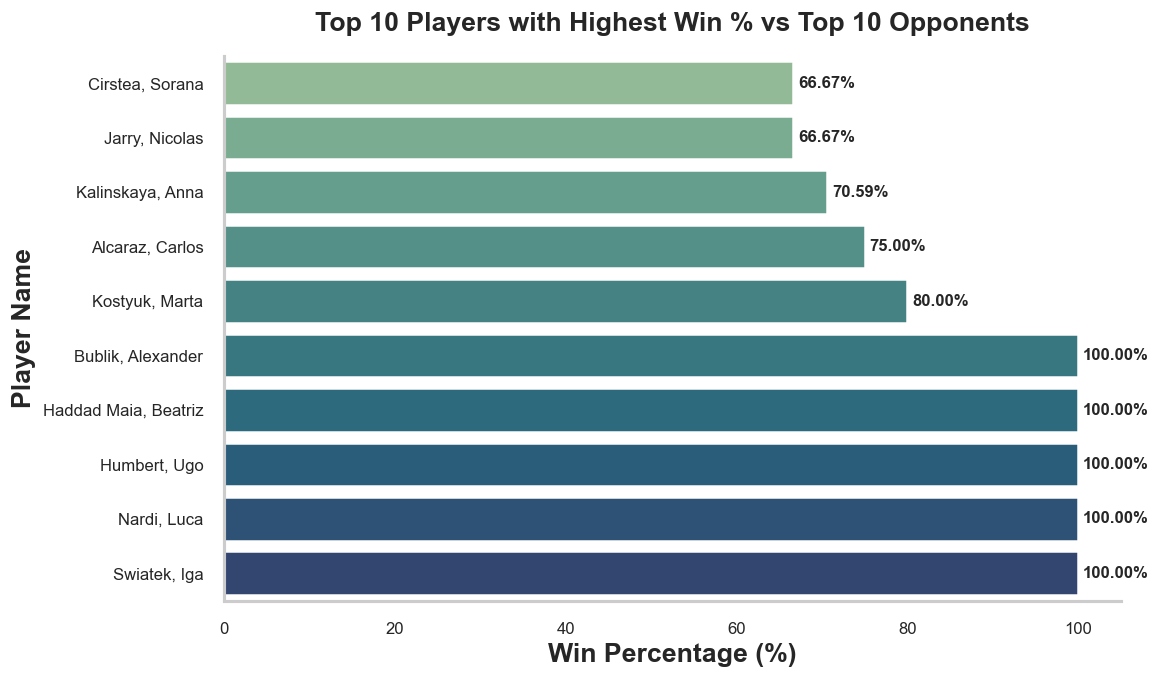

In [52]:

sns.set_theme(style="whitegrid", context="talk")

result_sorted = result.sort_values('win_percentage', ascending=True)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=result_sorted,
    y='full_name',
    x='win_percentage',
    palette='crest'
)

plt.title('Top 10 Players with Highest Win % vs Top 10 Opponents', 
          pad=15, fontsize=16, fontweight='bold', loc='center')
plt.xlabel('Win Percentage (%)', fontsize=16, fontweight='bold', loc='center')
plt.ylabel('Player Name', fontsize=16, fontweight='bold', loc='center')

ax.tick_params(axis='both', which='major', labelsize=10)
sns.despine()

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=10, fontweight='bold')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(False)

plt.tight_layout()
plt.savefig("top10_win_percentage_vs_top10.png", dpi=300, bbox_inches='tight')
plt.show()


🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 📊Question 17:  What is the average number of breaks of serve per match? 

In [53]:
breaks_of_serve_per_match = (
    power_df.groupby('match_id')
    .agg(
        false =('break_occurred', lambda x: (x == False).sum()),
        true =('break_occurred', lambda x: (x == True).sum())
    )
    .reset_index()
)
breaks_of_serve_per_match['total_break'] = breaks_of_serve_per_match['true']


avg = breaks_of_serve_per_match['total_break'].mean()
print(f'{avg}.2f')


14.180109702364895.2f


📋Answer:

Average breks of serve per match: 14.18

📝Methodology:

1-Group by match_id to aggregate breaks per match

2- Count break accurrences

3- Calculate means 


Keys:

✅On average there are approximately 14 breaks of serve, indicating that serve breaks occur roughly every 7th game.

✅On average(14.8) falls in the competitive range, indicating most matches are closely contested.

✅14.18 breaks per match indicates that professional tennis is a balanced spots where both serving and returning skills are equally important.

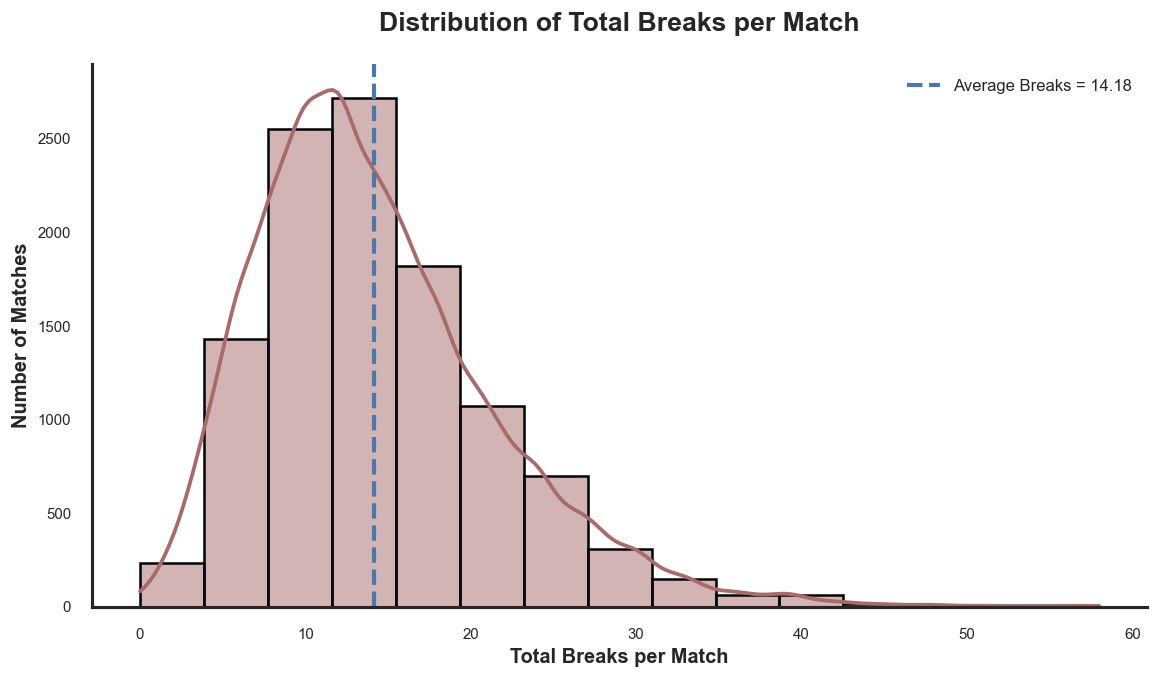

In [54]:
sns.set_theme(style="white", context="talk") 
plt.rcParams["figure.dpi"] = 120 

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=breaks_of_serve_per_match,
    x='total_break',
    bins=15,          
    kde=True,
    color="#A96A6A",  
    edgecolor="black",
    ax=ax
)


ax.axvline(
    avg,
    color="#4C78A8",  
    linestyle="--",
    linewidth=2.5,
    label=f"Average Breaks = {avg:.2f}" 
)


ax.set_title("Distribution of Total Breaks per Match", fontsize=16, fontweight='bold', pad=20, loc='center')
ax.set_xlabel("Total Breaks per Match", fontsize=12, fontweight='bold')
ax.set_ylabel("Number of Matches", fontsize=12, fontweight='bold')


ax.grid(False)
sns.despine(ax=ax) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



ax.legend(frameon=False, fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=9)

plt.savefig("my_plot17.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()



🎾 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🥇The End